In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import magnettools as mt
from magnettools.Bmap import display_table, getHoop, loadMagnet
from magnettools.Bmap_plot import create_plot, display_plot, plot_Hoop


Bval = None
Mdata = None
icurrents = None
Hoop_ = None




In [2]:
!pip install rainflow

--- Analyse temporelle : 4037 points ---
Analyse Rainflow terminée en 0.0017s
Cycles détectés : 313


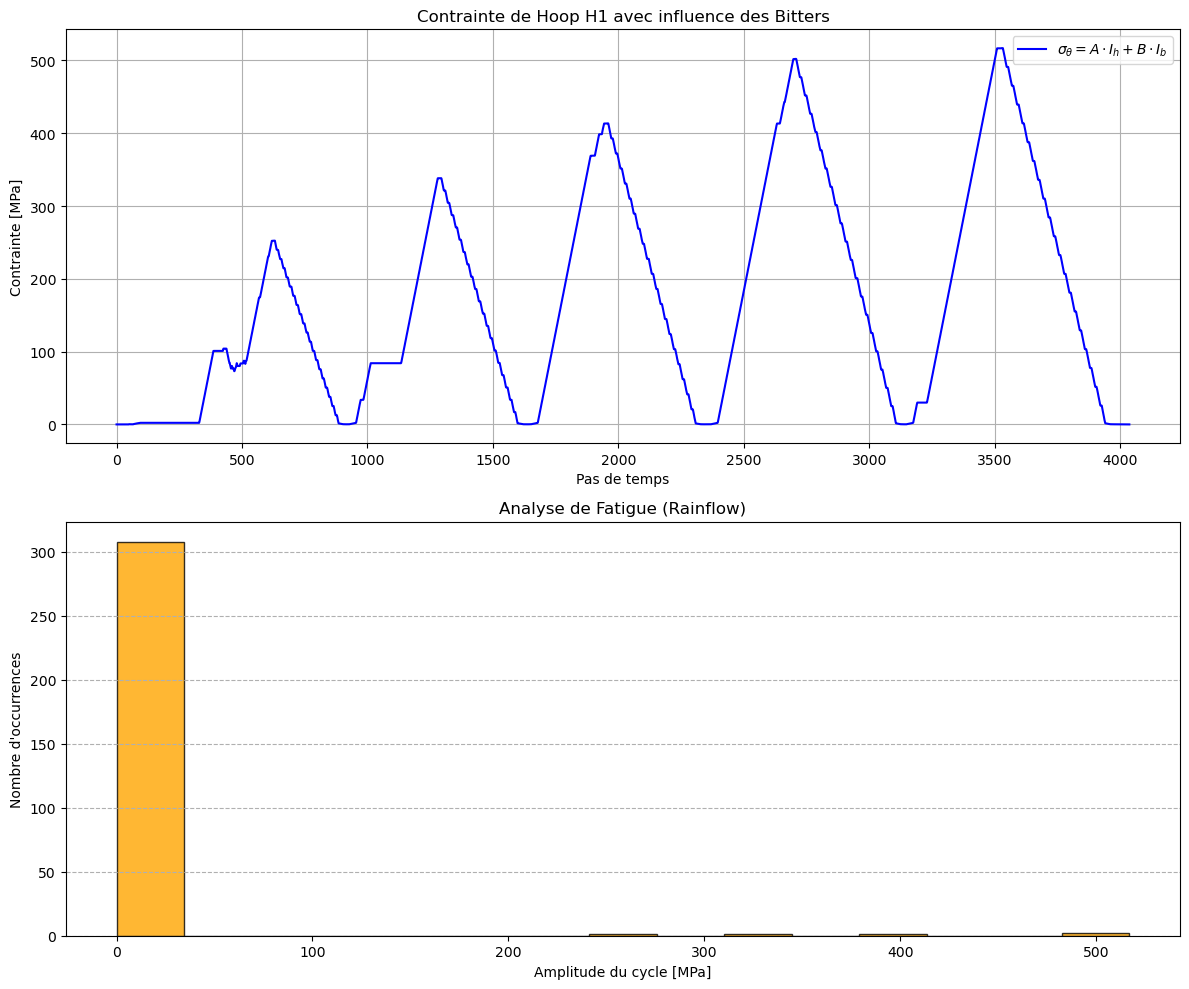

In [ ]:
import time
import rainflow 
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

base_data_path = "/workspaces/2026-m1-hifimagnet/python_magnetrun/data"
pupitre_file = os.path.join(base_data_path, "M9_2019.06.20-14_36_30.csv")


df = pd.read_csv(pupitre_file)


Ih = df['Icoil1'].values
Ib = df['Icoil15'].values + df['Icoil16'].values



coeff_A = 480 / 31000 
coeff_B = 40 / 30000   

sigma_theta = (coeff_A * np.abs(Ih)) + (coeff_B * np.abs(Ib))


print(f"--- Analyse temporelle : {len(sigma_theta)} points ---")
start_rf = time.time()
cycles = list(rainflow.count_cycles(sigma_theta))
print(f"Analyse Rainflow terminée en {time.time() - start_rf:.4f}s")
print(f"Cycles détectés : {len(cycles)}")

# 3. Affichage
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Graphe temporel
ax1.plot(sigma_theta, label=r"$\sigma_{\theta} = A\cdot I_h + B\cdot I_b$", color='blue')
ax1.set_title("Contrainte de Hoop H1 avec influence des Bitters")
ax1.set_xlabel("Pas de temps")
ax1.set_ylabel("Contrainte [MPa]")
ax1.grid(True)
ax1.legend()

# Histogramme Fatigue
amplitudes = [c[0] for c in cycles]
ax2.hist(amplitudes, bins=15, color='orange', edgecolor='black', alpha=0.8)
ax2.set_title("Analyse de Fatigue (Rainflow)")
ax2.set_xlabel("Amplitude du cycle [MPa]")
ax2.set_ylabel("Nombre d'occurrences")
ax2.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

import numpy as np
import matplotlib.pyplot as plt

import magnettools as mt
from magnettools.Bmap import (
    display_table,
    getHoop,
    loadMagnet,
)
from magnettools.Bmap_plot import create_plot, display_plot, plot_Hoop

import pandas as pd
import os

from python_magnetrun.magnetdata import load_magnetdata
from python_magnetrun.runetl import prepareData

base_data_path = "/workspaces/2026-m1-hifimagnet/python_magnetrun/data"
input_file = os.path.join(base_data_path, "HL-31.d")
pupitre_file = os.path.join(base_data_path, "M9_2019.02.14-23_00_38.txt")

def Bprofile(input_file):
    print(f"call loadMagnet {input_file}")
    global Mdata, Bval, Bmax, icurrents, mcurrents, Hoop_headers, Hoop_, Hoopmax_

    try:
        Mdata = loadMagnet(input_file)
    except:
        print(f"Failed to load {input_file}")
        return

    (Tubes, Helices, OHelices, BMagnets, UMagnets, Shims) = Mdata

    print("call Bprofile")
    icurrents = mt.get_currents(Tubes, Helices, BMagnets, UMagnets)
    mcurrents = icurrents

    Bz0 = mt.MagneticField(Tubes, Helices, BMagnets, UMagnets, 0, 0)[1]

    print("Bz(0)=", Bz0)
    print("size:", len(Tubes), len(BMagnets), len(UMagnets))
    print("Currents:", icurrents)

def validate_from_pupitre():
    global Mdata, icurrents, Hoop_headers, Hoop_


    Bprofile(input_file)


    print(f"\n--- Lecture du pupitre : {os.path.basename(pupitre_file)} ---")
    data = load_magnetdata(pupitre_file)
    prepareData(housing="M9", data=data)
    print(data.Keys)          # list of available field names
    df = data.Data

    print(f"Colonnes détectées : {df.columns.tolist()}")

    IH = df['IH'].iloc[0]

    IB = df['IB'].iloc[0]

    Is = 0
    print(f"Courants récupérés : Ih={IH} A, IB={IB} A")


    (Tubes, Helices, OHelices, BMagnets, UMagnets, Shims) = Mdata
    vcurrents = icurrents

    num = 0
    if len(Tubes):
        vcurrents[num] = IH
        num += 1
    if len(BMagnets):
        vcurrents[num] = IB
        num += 1

    currents = mt.DoubleVector(vcurrents)
    mt.set_currents(Tubes, Helices, BMagnets, UMagnets, OHelices, vcurrents)

    # 4. Calcul du Hoop Stress
    (Hoop_headers, Hoop_) = getHoop(Tubes, Helices, BMagnets, UMagnets)

    # 5. Extraction de H1 pour vérification
    h1_row = [r for r in Hoop_ if r[0] == 'H1']
    if h1_row:
        val_hoop = h1_row[0][Hoop_headers.index('Hoop[MPa]')]
        print(f"\n--- RÉSULTAT H1 VALIDÉ ---")
        print(f"Hoop Stress H1 : {val_hoop:.2f} MPa")
    else:
        print("Hélice H1 non trouvée.")


validate_from_pupitre()